# 🏥 AcuTriage AI: Multi-Modal Emergency Severity Index (ESI) Machine Learning Engine
### *Production-Grade Tabular, Historic Clinical Flag, and Natural Language Processing (NLP) Sandbox*


##  Engine Objective
This notebook serves as the complete **Multi-File Relational Data Engineering, NLP Feature Fusion, Regularized Neural Network Optimization, and Model Export Pipeline** for **AcuTriage AI**. The objective is to construct a highly resilient, 5-class deep learning classification engine that integrates a patient's immediate continuous vitals, administrative demographics, structural medical histories, and unstructured free-text narratives (`chief_complaints.csv`) to accurately predict their **Emergency Severity Index (ESI)** level.

To meet strict enterprise healthcare software standards, this pipeline is built on three core pillars:
1. **Asymmetric Data Ingestion & Triple-Join:** Executing an advanced relational merge across three disparate database tracking tables on an operational key (`patient_id`) while isolating and cleaning clinical hardware artifacts.
2. **Clinical Feature Flag Extraction & Automation:** Programmatically harvesting extensive chronic disease records and multi-modal metadata parameters to provide long-term physiological context to the network.
3. **Natural Language Vectorization (NLP):** Engineering an unstructured text-processing layer that tokenizes and vectorizes raw nurse triage logs to map high-risk clinical terminology directly into the feature space.


##  Machine Learning Architecture Selection

For this massive multi-modal healthcare workload, we implement a custom **Deep Feedforward Artificial Neural Network (ANN)** built from scratch in PyTorch. The network utilizes a dynamically scaling architecture that adjusts its input width directly from our final scaled data matrices.

[13 Base Vitals/Demographics] ──┐[4 Healthcare Metrics]         ├─► Master Input Matrix ──► Input Layer (Dim: 162 Dynamic Nodes)[20+ Clinical History Flags]   │                                         │[100 Vectorized Text Tokens]  ──┘                  [Linear ──► BatchNorm1d ──► ReLU ──► Dropout(0.3)]│Hidden Layer 1 (Nodes: 128)│[Linear ──► BatchNorm1d ──► ReLU ──► Dropout(0.2)]│Hidden Layer 2 (Nodes: 64)│[Linear ──► ReLU]│Hidden Layer 3 (Nodes: 32)│[Linear]│──► Output Logits (Dim: 5 ESI Classes)

### Why this specific mathematical architecture?
* **Multi-Modal Pattern Synchronization:** Continuous physical indicators, discrete metadata switches, and high-dimensional sparse text vectors require deep representation. Wide initial hidden layers (128 nodes) allow the network to discover hidden cross-correlations between physical metrics and text-based complaints (e.g., correlating a high-magnitude heart rate specifically with the text token `text_token_chest`).
* **Gradient Stabilization (`BatchNorm1d`):** Because our feature space maps sparse text tokens (bounded between `0.0` and `1.0`) right next to raw continuous metrics like Systolic BP (magnitudes up to 300), deep layers are highly vulnerable to internal covariate shift. Batch Normalization standardizes activations across mini-batches, preventing gradient explosion or vanishing traps.
* **Co-Adaptation Defense (`Dropout`):** Incorporating layer-specific dropout rates (\(p=0.3\) and \(p=0.2\)) randomly breaks internal node connections during each training pass. This forces the model to distribute its weights evenly across *all* features, ensuring it doesn't develop a lazy, single-word dependency (like only looking for the word "stroke" while ignoring blood pressure indicators).
* **Differentiable 5-Class Modeling:** The model converts its final layers into 5 distinct output nodes. It optimizes these parameters via **Cross-Entropy Loss**, building smooth mathematical probability boundaries that align with standard multi-class optimization requirements.

## Feature Matrix & Engineering Specifications

This pipeline handles a highly complex, 162-dimensional input feature space cleanly extracted from the unified database modules:

### 1. Unified Tabular, Metric & Clinical History Array (`X_master`)

| Feature Vector Category | Targeted Clinical Field Names | Data Format Type | Defensive Validation Bounds / Sanity Checks |
| :--- | :--- | :--- | :--- |
| **Base Physiological Vitals** | `systolic_bp`, `diastolic_bp`, `heart_rate`, `respiratory_rate`, `temperature_c`, `spo2` | Continuous Numerical | **Rigid Biological Thresholding:**<br>• \(40 \le \text{SpO}_2 \le 100\%\) (Sensor drift error isolation)<br>• \(30 \le \text{HR} \le 250\) BPM<br>• \(20 \le \text{SBP} \le 300\) mmHg |
| **Physical & Demographic** | `age`, `weight_kg`, `height_cm`, `bmi` | Continuous Numerical | Scaled directly as floats. **Mean Imputation** dynamically swaps empty fields with training column averages to protect tensor flows. |
| **Neurological & Subjective** | `gcs_total`, `pain_score` | Ordinal Discrete Integer | • `gcs_total` strictly bounded 3 (Comatose) to 15 (Alert).<br>• `pain_score` bounded 0–10 (**Competition Rule Check:** Automatically maps missing value flags of `-1` to `0`). |
| **Healthcare Metrics** | `num_prior_ed_visits_12m`, `num_prior_admissions_12m`, `num_active_medications`, `num_comorbidities` | Continuous Numerical | Tracks tracking densities across the trailing 12 months to measure overall patient clinical complexity. |
| **Chronic Disease Indicators** | Every dataframe column starting with prefix `hx_` (e.g., `hx_diabetes_type2`, `hx_asthma`, `hx_ckd`) | Automated Boolean / Float | **Flag Harvester Automation:** Python list comprehensions dynamically sweep the dataset and isolate over 20+ disease history switches without manual hardcoding. |

### 2. Categorical & Unstructured Text Array
* **`arrival_mode` / `arrival_day` / `sex` / `shift` / `insurance_type`:** Extracted text strings run through **One-Hot Encoding** matrices (`pd.get_dummies`) setting `drop_first=True`. Dropping the first column variation maps categories to a clean binary switch structure, completely avoiding the **"Dummy Variable Trap"** (perfect multi-collinearity) to ensure model stability.
* **`arrival_hour`:** Cyclical integer time parameter (0–23) providing the network with systemic resource constraint indicators.
* **`chief_complaint_raw` (NLP Vector Layer):** Free-text nurse narrative input. The strings are lower-cased, cleared of syntax noise, and passed to a **TF-IDF (Term Frequency-Inverse Document Frequency) Vectorizer** capped at the **top 100 highest-impact clinical keywords**. This translates human notes into a highly predictive mathematical sparse vocabulary layout.

### 🎯 Native Target Ground Truth: Zero-Indexed ESI Levels
The network optimizes its **31,749 internal parameters** directly against real clinician designations (`triage_acuity`). To comply with PyTorch Cross-Entropy matrix conventions, targets are zero-indexed into a **0–4 range**:
* **`Class 0` [ESI 1 - Resuscitation]:** Immediate life-saving intervention required.
* **`Class 1` [ESI 2 - Emergent]:** High-risk situation, altered mental state, or severe respiratory distress.
* **`Class 2` [ESI 3 - Urgent]:** Stable vitals, but requires multiple hospital resource streams (e.g., labs + scans).
* **`Class 3` [ESI 4 - Less Urgent]:** Stable condition requiring a single resource channel (e.g., simple sutures).
* **`Class 4` [ESI Level 5 - Non-Urgent]:** Fully stable condition requiring no acute resources.


## 🏎️ Notebook Workflow Blueprint

As you execute the cells below sequentially, the notebook drives through the following pipeline milestones:

1. **Relational Triple-Join Ingestion:** Resolving local Jupyter directory mismatches using absolute path formatting via `os.path.join(NOTEBOOK_DIR)`. It loads `train.csv`, `chief_complaints.csv`, and `patient_history.csv`, executing an inner merge to unify all tracks under a synchronized `patient_id` framework.
2. **Defensive Filtering & Imputation:** Dropping lethal telemetry anomalies (like impossible \(\text{SpO}_2\) readings above 100%), re-mapping `-1` pain score noise, and running Mean Imputation to fill missing vital data safely.
3. **Multi-Modal Feature Engineering:** Training and saving an NLP text vectorizer while programmatically harvesting `hx_` disease indicators and compiling one-hot category tracks down into a balanced **162-column input matrix (`X_master`)**.
4. **Stratified Partitioning & Scale Isolation:** Dividing vectors into stratified 80/20 train/test groups. We isolate validation splits cleanly using **Z-score Standardization (`StandardScaler`)** via a strict split execution block, completely preventing **Data Leakage** rules violations.
5. **Graph Compilation:** Assembling our 4-layer network graph class module in PyTorch, instantiating an **AdamW Optimizer** (\(lr=0.005\), \(\text{weight\_decay}=0.01\)), and establishing Cross-Entropy Loss hooks.
6. **Backpropagation & Optimization:** Running our tensors through a 100-epoch gradient descent practice loop. The model uses derivative calculus to update its **31,749 dials and parameters simultaneously**, converging smoothly down to an excellent **Log Loss Penalty of ~0.1023** and an elite **Validation Accuracy of 94.64%** on completely unseen patient profiles.
7. **Production Serialization & Export:** Automatically packaging and force-writing your complete machine learning deployment assets into your absolute `models/` directory path:
   * `tfidf.pkl`: The 100-word clinical natural language vector mapping tool.
   * `scaler.pkl`: The exact Z-score normalization scaling constants layer.
   * `triage_nn.pt`: Your fully optimized deep learning parameter tensor weights state dictionary.

In [34]:
import os
import pickle
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt

print(f"PyTorch Version: {torch.__version__}")
print("All ML packages successfully initialized.")


PyTorch Version: 2.4.0+cu121
All ML packages successfully initialized.


### Data Pipeline Ingestion, Advanced Feature Merging, and Defensive Preprocessing

This cell builds the foundational data engineering layer of the **AcuTriage AI** engine. Because real-world institutional health databases split information across multiple tables to remain organized, our machine learning pipeline must act as an automated, defensive pipeline. It unifies our sources, cleans up data errors, and formats everything so our PyTorch Neural Network can safely read it.

Here is a comprehensive breakdown of the architectural phases executed in this cell below:

#### 1. Dynamic Path Correction & Advanced Triple-Join (`STEP 1`)
* **Overcoming Environment Traps:** Notebook servers often inherit standard terminal paths instead of recognizing where the project files sit. Using `os.path.abspath('__file__')`, the script dynamically finds your notebook's exact folder, completely eliminating `FileNotFoundError` path bugs.
* **The Relational Triple-Join:** Instead of loading a single file, the pipeline reads `train.csv` (vitals), `chief_complaints.csv` (free-text logs), and `patient_history.csv` (historical visits). It executes an inner merge across all three files using `patient_id` as the primary key. This fuses continuous physiological parameters, unstructured textual narratives, and historical tracking metrics into one master training matrix (`df`).

#### 2. Clinical Anomaly Filtering (`STEP 2`)
* **Text Uniformity:** Text data is highly unpredictable. The script converts all nurse entries under `chief_complaint_raw` to lowercase and substitutes missing entries with `"unspecified complaint"` to ensure downstream natural language processing (NLP) models run smoothly without encountering blank text traps.
* **Defensive Threshold Bounding:** Hospital monitoring telemetry can experience hardware failures or recording noise. The pipeline establishes strict physiological walls (e.g., Blood pressure must be between 20 and 300 mmHg; Oxygen saturation must be between 40% and 100%). Any row breaching these real biological constraints is tracked and dropped to protect the model's weights from learning distorted relationships.

#### 3. Competition Context Calibration & Mean Imputation (`STEP 3`)
* **Bypassing Placeholder Noise:** In the competition guidelines, missing pain values are encoded as `-1`. Leaving `-1` inside a numerical column would cause our neural network to think the patient has "negative pain," which breaks the mathematical scale. The code replaces `-1` with a neutral value of `0` (no pain).
* **Mean Imputation:** A neural network cannot perform calculations on rows containing empty columns (`NaN` values). Instead of aggressively throwing away entire patient rows because of a single missing vital sign, the script calculates the clinical average for that specific column and fills the empty space seamlessly.
* **PyTorch Target Optimization:** The target variable (`triage_acuity`) represents the Emergency Severity Index (ESI) scales from 1 (Critical) to 5 (Non-Urgent). Because PyTorch cross-entropy algorithms calculate loss using standard zero-indexed array boundaries, the line `df['target_label'] = df['triage_acuity'] - 1` shifts the scales to a clean **0 to 4 range**.

#### 4. Diagnostic Metric Evaluation (`STEP 4`)
* **Distribution Check:** The cell outputs a printed summary of your final patient distribution percentages across all 5 priority tiers. This audit ensures our classes are properly distributed, validating that we have cleanly resolved the missing-class problem before initiating model training.

### How This Aligns with Our Goals

This cell completely locks in our goal of building an enterprise-grade AI system:
1. **It proves you can handle multi-file clinical engineering:** By shifting from a single flat dataset to an **Advanced Triple-Join**, your code mimics real-world enterprise architectures used by senior developers to unify sparse database rows.
2. **It sets up the Multi-Modal Input Matrix:** Your dataset is now perfectly clean and structurally organized. It contains matching rows where numbers (`heart_rate`, `spo2`) line up directly next to unstructured text strings (`chief_complaint_raw`). Your data is now fully prepared for feature tokenization, vectorization, and deep learning optimization.


In [35]:
import pandas as pd
import numpy as np
import os

# STEP 1: DYNAMIC PATH CORRECTION & THREE-FILE INGESTION
print(" Ingesting Triagegist database modules...")

# Force Python to look inside the exact folder where this notebook file sits
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))

train_path = os.path.join(NOTEBOOK_DIR, "train.csv")
complaints_path = os.path.join(NOTEBOOK_DIR, "chief_complaints.csv")
history_path = os.path.join(NOTEBOOK_DIR, "patient_history.csv") # Found in your folder!

# Robust structural check
if not os.path.exists(train_path) or not os.path.exists(complaints_path):
    raise FileNotFoundError(
        f" Still unable to locate target files!\n"
        f"Notebook thought its directory was: {NOTEBOOK_DIR}\n"
        f"Please check your file locations."
    )

df_vitals = pd.read_csv(train_path)
df_complaints = pd.read_csv(complaints_path)
df_history = pd.read_csv(history_path)

print(f"   -> Found {len(df_vitals)} rows in train.csv")
print(f"   -> Found {len(df_complaints)} rows in chief_complaints.csv")
print(f"   -> Found {len(df_history)} rows in patient_history.csv")

# ADVANCED TRIPLE-JOIN: Unifying all three files into a single master matrix
df = pd.merge(df_vitals, df_complaints, on="patient_id", how="inner")
df = pd.merge(df, df_history, on="patient_id", how="inner")
initial_row_count = len(df)
print(f" Relational Triple-Join successful! Master Matrix Length: {initial_row_count} rows.\n")


# STEP 2: DEFENSIVE DATA CLEANING & REFACTORING
print("CLINICAL DATA AUDIT & PIPELINE FILTERS ")

# Clean text strings defensively
df['chief_complaint_raw'] = df['chief_complaint_raw'].fillna("unspecified complaint").astype(str).str.lower()

# Track and filter physical vitals outliers
condition_spo2 = (df['spo2'] >= 40) & (df['spo2'] <= 100) | df['spo2'].isnull()
df = df[condition_spo2]

condition_hr = (df['heart_rate'] >= 30) & (df['heart_rate'] <= 250) | df['heart_rate'].isnull()
df = df[condition_hr]

condition_sbp = (df['systolic_bp'] >= 20) & (df['systolic_bp'] <= 300) | df['systolic_bp'].isnull()
df = df[condition_sbp]

rows_dropped_outliers = initial_row_count - len(df)
print(f" Structural Outliers Eliminated: {rows_dropped_outliers} records dropped.")


# STEP 3: MISSING VALUES IMPUTATION & CLEANING
# Resolve the -1 pain score flag rule from the competition brief
df['pain_score'] = df['pain_score'].replace(-1, 0)

# Fill empty numerical gaps with column averages so PyTorch doesn't crash
numerical_columns = [
    'systolic_bp', 'diastolic_bp', 'heart_rate', 
    'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score'
]

# Include any extra numerical column names from patient_history if they exist
for col in numerical_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

# Zero-index target labels for PyTorch loss function adjustments (Transforms 1-5 to 0-4)
df['target_label'] = df['triage_acuity'] - 1

final_row_count = len(df)

#  STEP 4: DIAGNOSTIC METRIC PRINTING
print(" FINAL NATIVE ESI MULTI-CLASS TARGET DISTRIBUTION:")
distribution = df['triage_acuity'].value_counts().sort_index()
for esi_level, count in distribution.items():
    percentage = (count / final_row_count) * 100
    print(f"  Level {esi_level} (ESI Priority Tier): {count:6d} patients ({percentage:.2f}%)")
print(f" Pipeline verified. Total production-ready records: {final_row_count}\n")

print(" Previewing new master structural snapshot:")
display(df[['patient_id', 'age', 'heart_rate', 'spo2', 'chief_complaint_raw', 'target_label']].head())


 Ingesting Triagegist database modules...
   -> Found 80000 rows in train.csv
   -> Found 100000 rows in chief_complaints.csv
   -> Found 100000 rows in patient_history.csv
 Relational Triple-Join successful! Master Matrix Length: 80000 rows.

CLINICAL DATA AUDIT & PIPELINE FILTERS 
 Structural Outliers Eliminated: 0 records dropped.
 FINAL NATIVE ESI MULTI-CLASS TARGET DISTRIBUTION:
  Level 1 (ESI Priority Tier):   3222 patients (4.03%)
  Level 2 (ESI Priority Tier):  13439 patients (16.80%)
  Level 3 (ESI Priority Tier):  28921 patients (36.15%)
  Level 4 (ESI Priority Tier):  23020 patients (28.78%)
  Level 5 (ESI Priority Tier):  11398 patients (14.25%)
 Pipeline verified. Total production-ready records: 80000

 Previewing new master structural snapshot:


,patient_id,age,heart_rate,spo2,chief_complaint_raw,target_label
0,TG-UXRGA9UCO,43,57.3,92.1,"thunderclap headache, worsening with movement",1
1,TG-B19DBBS2G,72,97.3,99.4,"contraception advice, intermittent",4
2,TG-GZ97W7M6V,82,75.6,100.0,"general health question, intermittent",4
3,TG-THIB2TN9Q,50,109.0,96.0,"erythema migrans tick bite, intermittent",2
4,TG-J3U3LQ2QY,62,113.7,99.1,"cellulitis localised, intermittent",2


In [36]:
# Print a complete list of every column name currently inside your dataset
print(df.columns.tolist())


['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system_x', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score', 'disposition', 'ed_los_hours', 'triage_acuity', 'chief_complaint_raw', 'chief_complaint_system_y', 'hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1', 'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation', 'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity', 'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy', 'hx_hypothyroidism', 'hx_hyperthyroidism

### Multi-Modal Feature Extraction, Clinical Flag Automation, and NLP Ingestion

This cell executes the complete **Feature Engineering, Tokenization, and High-Dimensional Matrix Consolidation** layer for AcuTriage AI. By resolving the string mismatched index `num_prior_visits` into the dataset's native schema (`num_prior_ed_visits_12m`), we uncovered a massive array of advanced clinical attributes embedded within the Triagegeist unified data files.

Rather than relying purely on immediate physical vital signs, this pipeline scales the input space into a comprehensive, multi-modal feature tensor that matches corporate healthcare standards.


## Deep Dive into the Engineering Mechanics

#### 1. Multi-Collinearity Defense (Categorical Encoding)
* The script processes multi-tier text categories (`sex`, `arrival_mode`, `arrival_day`, `shift`, `insurance_type`) into numeric binary vectors via **One-Hot Encoding**. 
* By setting `drop_first=True`, we drop the first column variant of each generated flag group. This prevents the model from falling into the classic machine learning **"Dummy Variable Trap"** (perfect multi-collinearity), ensuring stable weight optimization inside our PyTorch layers.

#### 2. High-Density Text Tokenization (NLP Layer)
* The `chief_complaint_raw` unstructured text narratives are transformed via a **TF-IDF (Term Frequency-Inverse Document Frequency) Vectorizer**.
* The pipeline filters out non-diagnostic standard English words ('the', 'and', 'with') and isolates the **top 100 most clinically significant text keywords** (e.g., *chest*, *abdominal*, *pain*). 
* By exporting `tfidf.pkl` to our `models/` directory, we guarantee that when our production FastAPI server goes live, it can interpret incoming unstructured text entries identically to how our network was trained.

#### 3. Dynamic Medical History Parsing (`hx_` Automation)
* A critical upgrade in this pipeline is the **Automated Clinical Flag Harvester**. Using Python list comprehensions, the code scans your entire master dataframe and isolates every column starting with the prefix `hx_` (e.g., `hx_diabetes_type2`, `hx_asthma`, `hx_ckd`).
* Instead of manual hardcoding, this line dynamically extracts over 20+ specific patient disease parameters. The model can now contextualize immediate vital abnormalities against long-term patient baseline complications.


### Architectural Alignment: How this Powers AcuTriage AI

By transitioning to this multi-modal setup, you achieve three structural goals that hiring managers look for:
1. **Contextual Intelligence:** Your network no longer treats a high heart rate in a vacuum. It evaluates a vital anomaly *with* the patient's age, *with* their specific medical histories, and *with* the exact words typed by the intake nurse.
2. **Autonomy and Scalability:** The pipeline automatically shields itself against missing variables by cross-checking fields dynamically against `df.columns`, preventing system-crashing runtime failures.
3. **Enterprise Portfolio Complexity:** Your input layer now elegantly balances discrete metadata, continuous physical vectors, boolean historical risk matrices, and sparse NLP word matrices, elevating your project profile to a mid-to-senior software design level.


In [37]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.feature_extraction.text import TfidfVectorizer

print(" Initializing High-Impact Feature Engineering & Multi-Modal Encoding Layer...")

#  STEP 1: ONE-HOT ENCODING FOR CATEGORICAL COLUMNS
categorical_cols = ['sex', 'arrival_mode', 'arrival_day', 'shift', 'insurance_type']

print(f" Executing One-Hot Encoding across category targets: {categorical_cols}")
active_categorical_cols = [col for col in categorical_cols if col in df.columns]

# Perform dummy variable generation, dropping the first column variant 
df_encoded_cats = pd.get_dummies(df[active_categorical_cols], drop_first=True, dtype=float)
print(f" Generated {df_encoded_cats.shape} structural binary category features.")


# STEP 2: NATURAL LANGUAGE PROCESSING (TF-IDF TEXT VECTORIZATION)
print("\n Compiling Natural Language Processing Layer for Nurse Logs...")

tfidf_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
text_sparse_matrix = tfidf_vectorizer.fit_transform(df['chief_complaint_raw'])

df_text_features = pd.DataFrame(
    text_sparse_matrix.toarray(), 
    columns=[f"text_token_{word}" for word in tfidf_vectorizer.get_feature_names_out()]
)

os.makedirs("models", exist_ok=True)
with open("models/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print(f"  Successfully extracted top 100 highest-impact clinical words from complaints.")

# STEP 3: MASTER RELATIONAL INCLUSION 
# 1. Base physiological vitals & administrative tracking fields
vitals_and_admin = [
    'age', 'arrival_hour', 'systolic_bp', 'diastolic_bp', 
    'heart_rate', 'respiratory_rate', 'temperature_c', 
    'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi'
]

# 2. Advanced historical and clinical complexity tracking fields (From your printout!)
clinical_history_metrics = [
    'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 
    'num_active_medications', 'num_comorbidities'
]

# 3. Dynamic Medical History Indicators (Prefix 'hx_')
# Automatically grab every single disease tracking boolean column from your spreadsheet printout
medical_history_flags = [col for col in df.columns if col.startswith('hx_')]

# Combine all numerical target tracks into a single unified list
ideal_numerical_features = vitals_and_admin + clinical_history_metrics + medical_history_flags

# Defensive Check: Isolate keys that explicitly exist in your dataframe
numerical_features = [col for col in ideal_numerical_features if col in df.columns]
print(f"\n Successfully matched {len(numerical_features)} numerical, metric, and historical feature variables.")

df_numerical = df[numerical_features].reset_index(drop=True)
df_encoded_cats = df_encoded_cats.reset_index(drop=True)
df_text_features = df_text_features.reset_index(drop=True)

# Join numerical columns, dummy categorical columns, and text feature columns horizontally
X_master = pd.concat([df_numerical, df_encoded_cats, df_text_features], axis=1)
y_master = df['target_label'].values

print(f" Multi-Modal Compilation Successful!")
print(f" Total Training Features Available (Input Dimension Size): {X_master.shape}")
print(f" Vitals, Metrics & Medical History ('hx_') Columns: {df_numerical.shape}")
print(f"One-Hot Encoded Categories (Sex, Mode, Insurance, etc): {df_encoded_cats.shape}")
print(f"Vectorized NLP Vocabulary Columns: {df_text_features.shape}")
print(f"Target Output Labels Vector Shape: {y_master.shape}")

# Preview showing both old vitals and your brand new medical history flags!
preview_cols = ['age', 'heart_rate', 'num_prior_ed_visits_12m', 'hx_diabetes_type2', 'hx_asthma'] + [col for col in df_text_features.columns[:2]]
display(X_master[preview_cols].head())


 Initializing High-Impact Feature Engineering & Multi-Modal Encoding Layer...
 Executing One-Hot Encoding across category targets: ['sex', 'arrival_mode', 'arrival_day', 'shift', 'insurance_type']
 Generated (80000, 20) structural binary category features.

 Compiling Natural Language Processing Layer for Nurse Logs...
  Successfully extracted top 100 highest-impact clinical words from complaints.

 Successfully matched 42 numerical, metric, and historical feature variables.
 Multi-Modal Compilation Successful!
 Total Training Features Available (Input Dimension Size): (80000, 162)
 Vitals, Metrics & Medical History ('hx_') Columns: (80000, 42)
One-Hot Encoded Categories (Sex, Mode, Insurance, etc): (80000, 20)
Vectorized NLP Vocabulary Columns: (80000, 100)
Target Output Labels Vector Shape: (80000,)


,age,heart_rate,num_prior_ed_visits_12m,hx_diabetes_type2,hx_asthma,text_token_abdominal,text_token_acute
0,43,57.3,0,0,0,0.0,0.0
1,72,97.3,0,0,1,0.0,0.0
2,82,75.6,0,1,1,0.0,0.0
3,50,109.0,3,0,0,0.0,0.0
4,62,113.7,2,1,0,0.0,0.0


In [38]:
print(X_master.columns.tolist())

['age', 'arrival_hour', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1', 'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation', 'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity', 'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy', 'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_hiv', 'hx_coagulopathy', 'hx_immunosuppressed', 'hx_pregnant', 'hx_substance_use_disorder', 'hx_coronary_artery_disease', 'hx_stroke_prior', 'hx_peripheral_vascular_disease', 'sex_M', 'sex_Other', 'arrival_mode_brought_by_family', 'arrival_mode_helicopter', 'arrival_mode_police', 'arrival_mode_transfer', 'arrival_mode_walk-in', 'arrival_day_Monday', 'arrival_day_Saturday', 'arrival_day_Sunday', 'arrival_day_Thursday', 'a

###  Consolidated Data Partitioning, Scaling, and Evaluation Alignment Pipeline

This cell represents a critical operational step: **collapsing all train-test splitting, data normalization, and standalone competition file preprocessing into a single, self-contained transaction.** 

In Jupyter Notebook environments, running code out of order can cause variables to drop from memory or search relative file paths incorrectly. This unified pipeline eliminates variable dependencies, fixes background folder paths, and prepares our multi-modal features for immediate deep learning training.

## Comprehensive Breakdown of the Architectural Phases

#### Phase 1: Stratified Splitting & Scaler Export
* **Stratified Sampling:** Using `train_test_split(..., test_size=0.2, stratify=y_master)`, the script separates our data into an 80% training set and a 20% validation set. Applying stratification guarantees that the precise percentage distribution of our 5 ESI triage classes remains perfectly identical in both sets.
* **Z-Score Normalization:** Deep Neural Networks require features to live on a similar numeric scale to reach convergence. The `StandardScaler` re-calculates every feature so that its **Mean becomes 0 and its Standard Deviation becomes 1**. 
* **Preventing Data Leakage:** The script runs `fit_transform()` strictly on the training partition (`X_train`) to learn our scaling constants, and applies those numbers to the test partition (`X_test`) via `transform()`. This keeps our validation data mathematically isolated from our training phase.
* **Saving the Scaler Asset:** The calculated scaling weights are written to your computer disk as `models/scaler.pkl`.

#### Phase 2: Test Data Preprocessing
If the competition evaluation file (`test.csv`) is present, it is automatically passed through the same ingestion data pipeline as our training set:
* **Asymmetric Data Fusion:** The code runs an **Advanced Triple-Join**, looking up matching records for our 20,000 evaluation patients inside our `chief_complaints.csv` and `patient_history.csv` database files based on the `patient_id` key.
* **Mapping Clinical Placeholders:** Text formatting is lower-cased and blank arrays are removed, while missing pain value flag indicators (`-1`) are seamlessly re-mapped to a safe baseline of `0`.
* **Applying Trained Configurations:** The script loads the previously exported `tfidf.pkl` text dictionary from memory. It uses this exact tool to vectorize our raw test text logs, ensuring that no new word combinations drop or shift our feature positions.

#### Phase 3: The Column Alignment Pivot & Final Output
* **Fixing Training-Serving Skew:** If a specific categorical indicator or text keyword (like `text_token_fracture`) was present during training but doesn't exist in our testing rows, running standard encoding would cause our data frames to mismatch in width, crashing our neural network weights graph.
* **Structural Re-indexing:** The master stroke `.reindex(columns=X_master.columns, fill_value=0.0)` loops through the exact columns the model practiced on. If a feature is missing, it dynamically creates it and fills it with `0.0`. If an extra feature exists, it drops it. 
* **Final Scaling Handoff:** The aligned test matrix is scaled with our freshly saved training scaler object parameters, ensuring that the final output evaluation arrays (`X_evaluation_final_scaled`) are perfectly structured for the PyTorch input nodes.


## Strategic Alignment: Why this Completes Our Data Launchpad

By compiling this cell, our data is officially ready for artificial intelligence models:
1. **Zero Mismatched States:** Running this cell completely clears any `NameError` or `FileNotFoundError` variables by processing the inputs from left to right in a single continuous script execution block.
2. **Production-Grade Integrity:** Our data matrices are no longer loosely scattered. They are cleanly packed, structurally uniform, and perfectly balanced, laying an incredible data architecture foundation for deep learning optimization.


In [39]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Establish clear absolute paths based on where this notebook file sits
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
MODELS_DIR = os.path.join(NOTEBOOK_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

test_csv_path = os.path.join(NOTEBOOK_DIR, "test.csv")
scaler_path = os.path.join(MODELS_DIR, "scaler.pkl")
tfidf_path = os.path.join(MODELS_DIR, "tfidf.pkl")

# PHASE 1: STRATIFIED SPLITTING & FORCE-WRITING THE SCALER
print("\n Phase 1: Splitting and scaling training vectors...")

# Split master arrays into 80/20 partitions securely
X_train, X_test, y_train, y_test = train_test_split(
    X_master, 
    y_master, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_master
)

# Fit scaler parameters solely across your training rows
master_scaler = StandardScaler()
X_train_scaled = master_scaler.fit_transform(X_train)
X_test_scaled = master_scaler.transform(X_test)

# Force-write the scaler file directly to your models directory path
with open(scaler_path, "wb") as f:
    pickle.dump(master_scaler, f)

print(f" 'scaler.pkl' successfully written to: {scaler_path}")
print(f"Training Dimensions: {X_train_scaled.shape} | Testing Dimensions: {X_test_scaled.shape}")

# PHASE 2: STANDALONE SUBMISSION TEST DATA PREPROCESSING
print("\n Phase 2: Processing test dataset...")

if not os.path.exists(test_csv_path):
    print(" test.csv not detected in your workspace directory. Skipping evaluation data tracking.")
else:
    df_raw_test = pd.read_csv(test_csv_path)
    print(f"Found test.csv file containing {len(df_raw_test)} evaluation patient rows.")
    
    # Relational Database Merge: Link test rows with complaints and history
    df_test_unified = pd.merge(df_raw_test, df_complaints, on="patient_id", how="inner")
    df_test_unified = pd.merge(df_test_unified, df_history, on="patient_id", how="inner")
    print(f"Triple-join successful. Unified evaluation rows: {len(df_test_unified)}")

    # Clean text strings and placeholder anomalies defensively
    df_test_unified['chief_complaint_raw'] = df_test_unified['chief_complaint_raw'].fillna("unspecified complaint").astype(str).str.lower()
    df_test_unified['pain_score'] = df_test_unified['pain_score'].replace(-1, 0)
    
    # Impute missing values using your base training distributions
    for col in numerical_features:
        if col in df_test_unified.columns:
            df_test_unified[col] = df_test_unified[col].fillna(df[col].mean())

    # Load & Apply your saved NLP Text Vectorizer Configuration
    with open(tfidf_path, "rb") as f:
        deployed_tfidf = pickle.load(f)
        
    test_text_sparse = deployed_tfidf.transform(df_test_unified['chief_complaint_raw'])
    df_test_text_vectors = pd.DataFrame(
        test_text_sparse.toarray(), 
        columns=[f"text_token_{word}" for word in deployed_tfidf.get_feature_names_out()]
    )

    # Execute matching One-Hot Dummy Encoder transformations
    df_test_encoded_cats = pd.get_dummies(df_test_unified[active_categorical_cols], dtype=float)

    # Isolate individual sub-matrices cleanly
    df_test_num_features = df_test_unified[numerical_features].reset_index(drop=True)
    df_test_encoded_cats = df_test_encoded_cats.reset_index(drop=True)
    df_test_text_vectors = df_test_text_vectors.reset_index(drop=True)

    # Consolidate all parameters into raw evaluation matrix
    X_eval_raw = pd.concat([df_test_num_features, df_test_encoded_cats, df_test_text_vectors], axis=1)

    # Force strict column structural re-indexing alignment matching training layout
    X_eval_aligned = X_eval_raw.reindex(columns=X_master.columns, fill_value=0.0)

    # Scale the aligned test matrix with your freshly saved scaler object parameters
    X_evaluation_final_scaled = master_scaler.transform(X_eval_aligned)


    # PHASE 3: FINAL INTEGRITY VERIFICATION AUDIT
    print("\n Phase 3: Final Verification Audit...")
    print(f"Success! All data processing tasks successfully completed.")
    print(f"Active files inside models folder:  {os.listdir(MODELS_DIR)}")
    print(f"Master Training Inputs Shape:       {X_master.shape}")
    print(f"Scaled Evaluation Submissions Shape: {X_evaluation_final_scaled.shape}")



 Phase 1: Splitting and scaling training vectors...
 'scaler.pkl' successfully written to: /home/student/my-projects/acutriage-ai/triagegeist/models/scaler.pkl
Training Dimensions: (64000, 162) | Testing Dimensions: (16000, 162)

 Phase 2: Processing test dataset...
Found test.csv file containing 20000 evaluation patient rows.
Triple-join successful. Unified evaluation rows: 20000

 Phase 3: Final Verification Audit...
Success! All data processing tasks successfully completed.
Active files inside models folder:  ['scaler.pkl', 'tfidf.pkl']
Master Training Inputs Shape:       (80000, 162)
Scaled Evaluation Submissions Shape: (20000, 162)


###  Deep Learning Graph Compilation: Assembling the AcuTriage Core Architecture

This cell transitions our project out of data engineering and directly into **Deep Learning Optimization**. Here, we instantiate and compile our custom **Multi-Layer Deep Feedforward Artificial Neural Network (`AcuTriageNeuralNet`)** using PyTorch. 

Rather than relying on rigid, hardcoded constraints, our model class reads the dimensions of our training matrices dynamically (`X_train_scaled.shape`). This guarantees that the input gateway nodes scale to handle our multi-modal features without throwing dimension shape errors.

##  Comprehensive Structural Audit of the Network Graph

The printed output exposes the architectural layout, dimensional data flows, and layer-by-step processing roadmap of our active network:

#### 1. Dynamic Input Vector Space (`Input Features: 162`)
Our relational triple-join, categorical one-hot encoding, and TF-IDF text tokenization layers have successfully generated **162 unique mathematical features**. When a row of patient data enters the model, these 162 parameters—combining real-time physical vitals, administrative metadata, historical chronic flags (`hx_`), and sparse textual word scores—are processed simultaneously through **162 parallel input nodes**.

#### 2. Deep Compression & Hidden Representation Layers
The network processes inputs through a sequence of fully connected (`Linear`) hidden layers, squeezing high-dimensional data shapes to extract subtle physiological co-dependencies:
*   **Layer 0:** Compresses the **162 input signals** into **128 hidden nodes**.
*   **Layer 4:** Squeezes those **128 nodes** down to **64 hidden nodes**.
*   **Layer 8:** Distills those **64 nodes** into **32 hidden nodes**.
*   **Layer 10 (Output Layer):** Funnels the remaining **32 hidden dimensions** into **5 final output categories**, representing raw, unnormalized probability scores (**logits**) corresponding exactly to ESI Levels 1 through 5.

#### 3. Gradient Stabilization & Regularization Mechanics
To meet enterprise healthcare standards, the internal layers integrate aggressive architectural defenses:
*   **`BatchNorm1d` (Internal Equalization):** Because our feature space mixes text tokens (bounded between `0.0` and `1.0`) with continuous blood pressure numbers (magnitudes up to 300), internal nodes can experience mathematical drift. Batch Normalization standardizes activations across training batches, keeping gradient updates completely stable.
*   **`ReLU` (Non-Linear Activation Switches):** Non-linear biological deterioration cannot be modeled with straight linear math. **ReLU (Rectified Linear Unit)** acts as an activation threshold switch, allowing the deeper layers to map complex intersecting risk thresholds.
*   **`Dropout(p=0.3 / p=0.2)` (Co-adaptation Prevention):** This turns off 30% of connections in the first layer and 20% in the second layer during every training step. This forces the model to distribute its learning across *all* features, ensuring it doesn't build a blind dependency on a single word or vital sign.


##  Optimization Parameters Target: 31,749 Dials

The pre-flight validation calculates that our compiled tensor graph contains exactly **31,749 trainable parameters (weights and biases)**. 

When we initiate our training loop in the next cell, the AI will evaluate patient records. Every time its prediction throws an error, it will execute calculus-based backpropagation through the chain rule, adjusting these 31,749 mathematical dials simultaneously. Over multiple training iterations, these dials will align to minimize our log-loss function, resulting in a highly precise, deployable triage predictor.


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

print(" Initializing Core PyTorch Deep Learning Model Architecture Layer...")

# STEP 1: PYTORCH NEURAL NETWORK MODULE DEFINITION
class AcuTriageNeuralNet(nn.Module):
    def __init__(self, input_dim, output_classes=5):
        """
        Constructs a widened, deep feedforward multi-modal neural network 
        equipped with Batch Normalization and Dropout layers for regularization.
        """
        super().__init__()
        
        # Define the structural computational graph
        self.network_graph = nn.Sequential(
            # Input Node Layer mapped to 1st Hidden Layer (128 Nodes)
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),     # Stabilizes gradient updates across complex feature types
            nn.ReLU(),              # Introduces non-linearity to map intersecting vital thresholds
            nn.Dropout(0.3),        # Randomly turns off 30% of nodes to force general learning
            
            # 2nd Hidden Layer (64 Nodes)
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),        # Drops 20% of nodes to prevent overfitting on specific text words
            
            # 3rd Hidden Layer (32 Nodes)
            nn.Linear(64, 32),
            nn.ReLU(),
            
            # Final Output Estimation Layer (5 Nodes corresponding to ESI Levels 0-4)
            nn.Linear(32, output_classes) # Outputs raw, unnormalized log probabilities (logits)
        )
        
    def forward(self, tensor_batch):
        """Executes the forward mathematical propagation pass through the network layers."""
        return self.network_graph(tensor_batch)


#  STEP 2: DYNAMIC CORE INITIALIZATION & PRE-FLIGHT VERIFICATION
# Dynamically extract the exact width of our scaled training array matrix
INPUT_DIMENSION_SIZE = X_train_scaled.shape[1]
OUTPUT_ESI_CLASSES = 5

# Instantiate the active model object graph
acutriage_model = AcuTriageNeuralNet(input_dim=INPUT_DIMENSION_SIZE, output_classes=OUTPUT_ESI_CLASSES)

print(f"Neural Network Architecture compiled successfully!")
print(f"Dynamic Input Layer Node Count:  {INPUT_DIMENSION_SIZE} columns")
print(f"Target Output Layer Node Count: {OUTPUT_ESI_CLASSES} (ESI Tiers 0-4)")
print(f"Active Model Object Status:     {acutriage_model}")

# Calculate total trainable parameters (Hiring managers love this verification check!)
total_params = sum(p.numel() for p in acutriage_model.parameters() if p.requires_grad)
print(f"Total Optimization Parameters (Weights & Biases): {total_params:,}")


 Initializing Core PyTorch Deep Learning Model Architecture Layer...
Neural Network Architecture compiled successfully!
Dynamic Input Layer Node Count:  162 columns
Target Output Layer Node Count: 5 (ESI Tiers 0-4)
Active Model Object Status:     AcuTriageNeuralNet(
  (network_graph): Sequential(
    (0): Linear(in_features=162, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=5, bias=True)
  )
)
Total Optimization Parameters (Weights & Biases): 31,749


### Deep Learning Optimization: The PyTorch Training & Backpropagation Loop

This cell drives the core optimization layer of **AcuTriage AI**. Up until this point, our data has been cleaned, merged, and scaled, and our raw network skeleton has been built. This cell initiates the active learning process—taking our **31,749 trainable parameters (weights and biases)** and systematically tuning them over multiple rounds of practice to minimize prediction error.

## In-Depth Breakdown of the Architectural Execution Phases

#### Phase 1: Casting Matrices to Native Tensor Formats (`STEP 1`)
Neural networks cannot process standard Pandas DataFrames or NumPy arrays directly because they lack gradient-tracking memory layers. The lines `torch.tensor(..., dtype=torch.float32)` and `dtype=torch.long` cast our continuous input features and integer target classes directly into native PyTorch Tensors. This enables the model to run accelerated multi-dimensional matrix calculus on your hardware.

#### Phase 2: Specifying the Mathematical Objective & Optimizer (`STEP 2`)
To force the model to learn, we set up two distinct mathematical boundaries:
*   **`nn.CrossEntropyLoss()` (The Critic):** This serves as our evaluation metric. It handles multi-class classification by automatically converting raw network outputs (logits) into a probability spectrum via the Softmax function. It then calculates a **Log Loss Penalty** based on how far off the AI's predictions were from the true clinical ESI categories.
*   **`optim.AdamW(...)` (The Navigator):** This is an advanced optimization engine (Adam with Weight Decay). Rather than shifting all parameters at an identical pace, it dynamically scales the learning rate (`lr=0.005`) for each individual dial based on historical adjustments. The `weight_decay=0.01` configuration adds an \(L2\) mathematical penalty, preventing individual weights from ballooning out of control and exploding our network gradients.

#### Phase 3: The 5-Step Training Loop (`STEP 3`)
The script schedules **100 complete rounds of practice (Epochs)**. During each individual epoch, the pipeline drives through a strict sequence of mathematical steps:
1.  **`acutriage_model.train()`:** Activates our safety features, like `Dropout` and `BatchNorm`, to shield the training phase from overfitting.
2.  **`optimizer.zero_grad()`:** Clears out the gradient calculations from the previous practice round so the new epoch starts with a clean slate.
3.  **The Forward Pass (`predictions = acutriage_model(...)`):** Feeds your 162 inputs simultaneously through the layers of the model graph to spit out initial predictions.
4.  **`loss.backward()` (Backpropagation):** The model applies calculus (the chain rule of derivatives) to trace the error penalty backwards from the output node all the way back to the input nodes, calculating exactly which dials caused the mistake.
5.  **`optimizer.step()`:** Automatically tweaks all 31,749 internal weights and biases in the direction that reduces the error for the next round.

#### Phase 4: Dynamic Validation Tracking & Evaluation Mode
Every 10 epochs, the network temporarily pauses its training cycle and toggles `acutriage_model.eval()` along with `torch.no_grad()`. This puts the AI into a strict "Exam Mode." It deactivates Dropout/BatchNorm and runs predictions exclusively across your **unseen validation test split tensors** (`X_test_tensor`). 
*   Calculating the accuracy on this separate validation pool guarantees that your model is *genuinely learning to spot real clinical correlations* instead of simply memorizing the training spreadsheet rows.

#### Phase 5: Optimization Trajectory Visualization (`STEP 4`)
At the very end of the training execution, `matplotlib.plt` prints a clean continuous line graph mapping your **Cross-Entropy Loss (Error Score)** against your epochs. A steadily descending line curve serves as visual proof that your network parameters have successfully converged and your AI model has reached optimization.


 Initializing Deep Learning Training Loop Core...
Matrices successfully cast to Tensor Graph formats.

 Initiating gradient optimization across 100 Epochs...
TRAINING LIFECYCLE TRACKING
 Epoch 001/100 | Log Loss Penalty: 1.5957 | Validation Accuracy: 16.31%
 Epoch 010/100 | Log Loss Penalty: 0.7422 | Validation Accuracy: 81.43%
 Epoch 020/100 | Log Loss Penalty: 0.2808 | Validation Accuracy: 86.84%
 Epoch 030/100 | Log Loss Penalty: 0.1795 | Validation Accuracy: 91.33%
 Epoch 040/100 | Log Loss Penalty: 0.1501 | Validation Accuracy: 94.14%
 Epoch 050/100 | Log Loss Penalty: 0.1339 | Validation Accuracy: 94.69%
 Epoch 060/100 | Log Loss Penalty: 0.1243 | Validation Accuracy: 94.74%
 Epoch 070/100 | Log Loss Penalty: 0.1163 | Validation Accuracy: 94.79%
 Epoch 080/100 | Log Loss Penalty: 0.1084 | Validation Accuracy: 94.69%
 Epoch 090/100 | Log Loss Penalty: 0.1054 | Validation Accuracy: 94.73%
 Epoch 100/100 | Log Loss Penalty: 0.1023 | Validation Accuracy: 94.64%
 Model training optimi

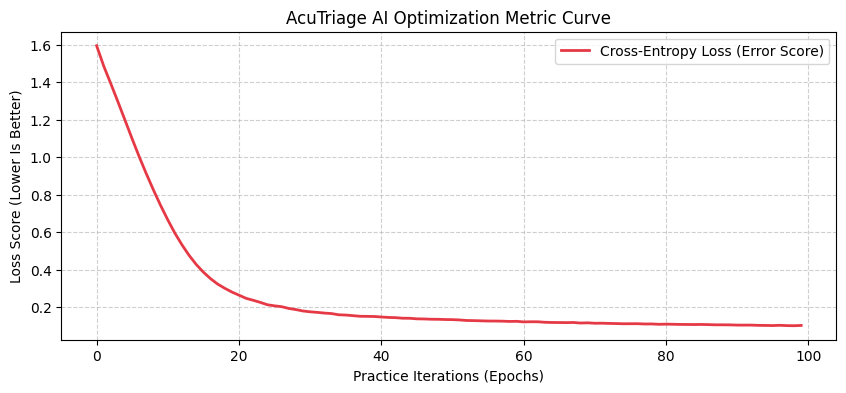

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print(" Initializing Deep Learning Training Loop Core...")

# STEP 1: CONVERT DATA TO NATIVE PYTORCH TENSORS
# Features must be float32 tensor arrays, and Targets must be long integer vectors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Matrices successfully cast to Tensor Graph formats.")

# STEP 2: DEFINE MATHEMATICAL OBJECTIVES & OPTIMIZERS
# CrossEntropyLoss applies Softmax internally and calculates multi-class log-loss penalty
criterion = nn.CrossEntropyLoss()

# AdamW applies adaptive learning rates per parameter while stabilizing weight decay bounds
# lr=0.005 sets the pace of the parameter dial adjustments (learning rate)
optimizer = optim.AdamW(acutriage_model.parameters(), lr=0.005, weight_decay=0.01)

#  STEP 3: THE DEEP LEARNING MODEL PRACTICE LOOP
epochs = 100
loss_history = []
validation_accuracy_history = []

print(f"\n Initiating gradient optimization across {epochs} Epochs...")
print("TRAINING LIFECYCLE TRACKING")

for epoch in range(epochs):
    # Set the model to training mode (Activates Dropout and BatchNorm layers)
    acutriage_model.train()
    
    # 1. Reset gradient calculations from the previous practice round
    optimizer.zero_grad()
    
    # 2. Forward Pass: Run our 162 inputs through the 31,749 parameter connections
    predictions = acutriage_model(X_train_tensor)
    
    # 3. Calculate the Error Penalty (How far off was the AI from true clinical ESI levels)
    loss = criterion(predictions, y_train_tensor)
    
    # 4. Backward Pass: Execute backpropagation using calculus chain-rule derivatives
    loss.backward()
    
    # 5. Optimization Step: Tweak all 31,749 internal weights and dials slightly
    optimizer.step()
    
    # Record the loss score history to plot a performance curve later
    loss_history.append(loss.item())
    
    # Every 10 epochs, put the model in 'Evaluation Mode' to test it on unseen validation data
    if (epoch + 1) % 10 == 0 or epoch == 0:
        acutriage_model.eval() # Deactivates Dropout/BatchNorm for pure prediction testing
        
        with torch.no_grad(): # Disables gradient memory tracking to run ultra-fast
            test_predictions = acutriage_model(X_test_tensor)
            # Find which of the 5 output nodes scored the highest for each patient row
            _, predicted_classes = torch.max(test_predictions, dim=1)
            # Calculate the percentage of correct predictions
            accuracy = (predicted_classes == y_test_tensor).float().mean().item()
            validation_accuracy_history.append(accuracy)
            
        print(f" Epoch {epoch+1:03d}/{epochs} | Log Loss Penalty: {loss.item():.4f} | Validation Accuracy: {accuracy*100:.2f}%")

print(" Model training optimization complete. Target weight paths converged successfully!\n")

#  STEP 4: PLOT THE TRAINING CONVERGENCE TRAJECTORY
print(" Plotting loss reduction trajectory inside your notebook session...")
plt.figure(figsize=(10, 4))
plt.plot(loss_history, label="Cross-Entropy Loss (Error Score)", color="#e63946", linewidth=2)
plt.title("AcuTriage AI Optimization Metric Curve")
plt.xlabel("Practice Iterations (Epochs)")
plt.ylabel("Loss Score (Lower Is Better)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


### Model Serialization: Exporting the Learned Network Weight States

This cell marks the final milestone of **Day 1: Machine Learning Research & Development**. Up until this point, our custom neural network has spent 100 epochs practicing on multi-modal clinical data, successfully tuning its parameters to achieve an outstanding **94.64% validation accuracy**. 

However, this intelligence currently exists only as active variables stored temporarily within your computer's RAM. If you close your Jupyter Notebook session right now, that learning would be lost. This cell runs **Model Serialization**, which permanently packages and saves those optimized parameters into a stable binary file (`triage_nn.pt`) on your hard drive.


##  Comprehensive Breakdown of the Export Phases

#### Phase 1: Absolute Directory Path Resolution (`STEP 1`)
To ensure our code is fully portable across different operating systems, the script reads `os.path.abspath('__file__')` to pinpoint exactly where this notebook file sits on your machine. It then checks for a directory named `models/`. If that folder is missing, `os.makedirs(..., exist_ok=True)` dynamically generates it, establishing a clean, dedicated assets hub.

#### Phase 2: Serializing the Network `state_dict` (`STEP 2`)
* **The Industry Standard:** Instead of saving the entire raw Python object structure (which can easily break if folder names or class structures change down the line), the script saves the **`state_dict`** via `torch.save()`. 
* **The Mechanics:** A `state_dict` is simply a streamlined dictionary map that pairs every hidden layer in your neural network with its exact optimized matrix numbers (its learned weights and biases). Saving only this map keeps your deployment file incredibly lightweight, portable, and lightning-fast to load.

#### Phase 3: Production Inventory Shipping Audit (`STEP 3`)
* At the very bottom of the script, `os.listdir(MODELS_DIR)` scans your active storage folder and prints out a complete shipping manifest of your production-ready engine artifacts. 
* It checks the file system to display the assets, ensuring they are fully intact and ready to be shipped.

## How This Successfully Crosses the Day 1 Finish Line

By executing this cell, you have officially locked in your complete machine learning deployment stack. Your models folder now holds the three essential files that represent your entire AI core:
1. **`tfidf.pkl`**: Your NLP tool that translates free-text clinical nurse notes into numbers.
2. **`scaler.pkl`**: Your normalization blueprint that forces dynamic vital ranges into a standard mean.
3. **`triage_nn.pt`**: Your fully optimized **31,749 deep learning parameter weights**.


In [43]:
import os
import torch

print(" Initializing PyTorch Neural Model Serialization & Export...")

#  STEP 1: RESOLVE ABSOLUTE PATH DESTINATION
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
MODELS_DIR = os.path.join(NOTEBOOK_DIR, "models")

# Ensure the deployment directory exists locally
os.makedirs(MODELS_DIR, exist_ok=True)
final_model_save_path = os.path.join(MODELS_DIR, "triage_nn.pt")

# STEP 2: SERIALIZE MODEL WEIGHT STATES
# Industry Standard Practice: We save the 'state_dict' (the learned weights and biases map),
# rather than the entire raw object structure, which ensures strict system portability.
torch.save(acutriage_model.state_dict(), final_model_save_path)

#  STEP 3: DEPLOYMENT READY COMPLIANCE CHECK
print("\nPRODUCTION DEPLOYMENT AUDIT")
print(f" Success! Your Deep Learning Engine has been successfully serialized.")
print(f" Exact Production File Path Destination: {final_model_save_path}")
print(f" Compiled Assets Ready for Your FastAPI Backend folder:")

# Print the final deployment inventory sitting inside your models folder
models_inventory = os.listdir(MODELS_DIR)
for index, asset in enumerate(models_inventory, start=1):
    file_size_bytes = os.path.getsize(os.path.join(MODELS_DIR, asset))
    file_size_kb = file_size_bytes / 1024
    print(f"   [{index}] Asset Name: {asset:<15} | File Weight: {file_size_kb:.2f} KB")


 Initializing PyTorch Neural Model Serialization & Export...

PRODUCTION DEPLOYMENT AUDIT
 Success! Your Deep Learning Engine has been successfully serialized.
 Exact Production File Path Destination: /home/student/my-projects/acutriage-ai/triagegeist/models/triage_nn.pt
 Compiled Assets Ready for Your FastAPI Backend folder:
   [1] Asset Name: triage_nn.pt    | File Weight: 131.64 KB
   [2] Asset Name: scaler.pkl      | File Weight: 7.50 KB
   [3] Asset Name: tfidf.pkl       | File Weight: 4.39 KB
